In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('/content/Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop('Cabin', axis=1, inplace=True)

/tmp/ipykernel_1906/792774890.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1906/792774890.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

Question:1 Create a countplot to show the number of passengers by gender.

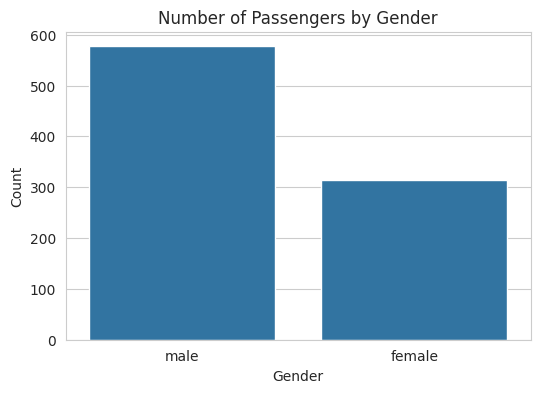

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)

plt.title('Number of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Interpretation

Male passengers are much higher than female passengers.

Most passengers on Titanic were males.

Question:2 Create a bar chart to show the number of passengers in each passenger class using different colors.

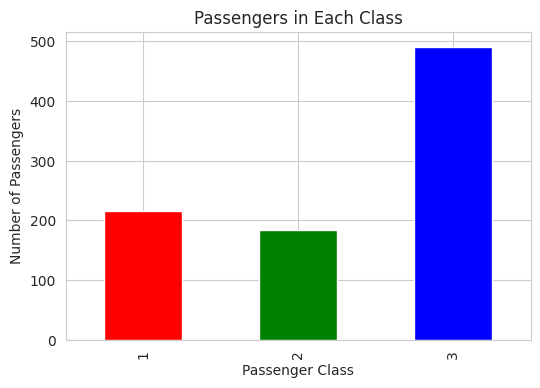

In [9]:
plt.figure(figsize=(6,4))

df['Pclass'].value_counts().sort_index().plot(
    kind='bar',
    color=['red','green','blue']
)

plt.title('Passengers in Each Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

Interpretation

Class 3 has the highest number of passenger.

Class 1 has the lowest number of passengers.


Question:3 Create a histogram to show the distribution of passenger age.

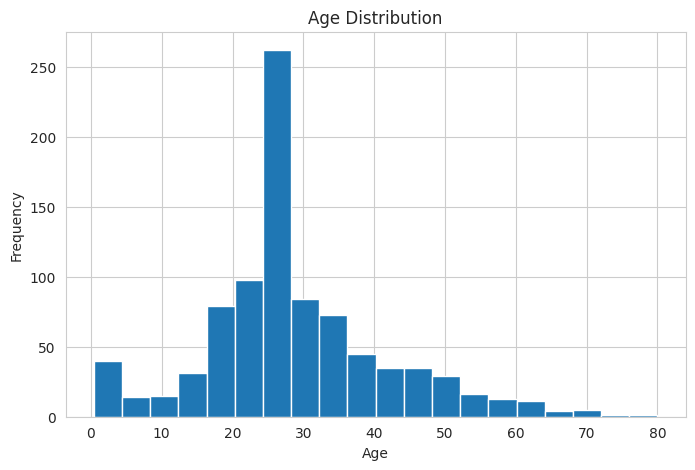

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Interpretation

Most passengers were between 20–40 years old.

Very few passengers were above 60 years.

Question:4 Create a boxplot to detect outliers in the fare column.

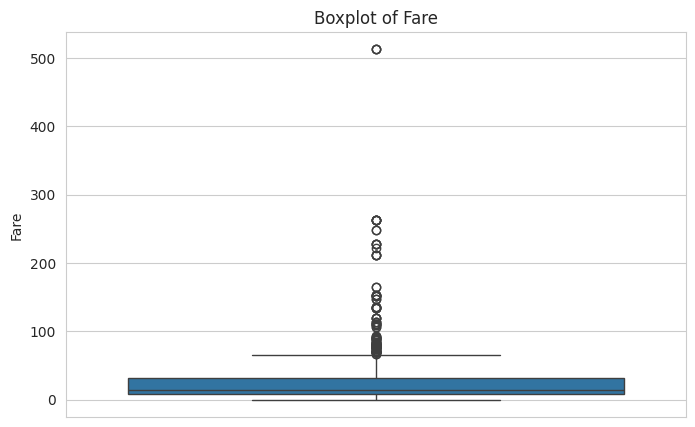

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(y='Fare', data=df)

plt.title('Boxplot of Fare')
plt.show()

Interpretation

Many outliers are present.

Some passengers paid extremely high fares.

Fare distribution is right-skewed.

Question:5 Create a scatterplot to

a. show the relationship between age and fare.

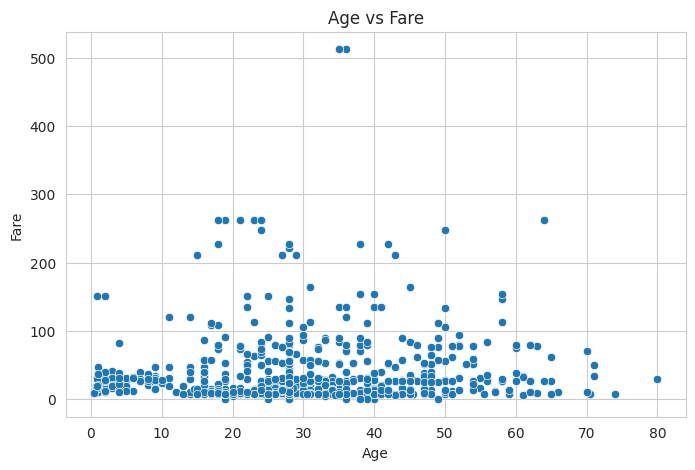

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Age', y='Fare', data=df)

plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

Interpretation

No strong relationship exists between age and fare.

High fare passengers belong to different age groups.

b. analyze the relationship between family size (SibSp + Parch) and fare.

In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch']

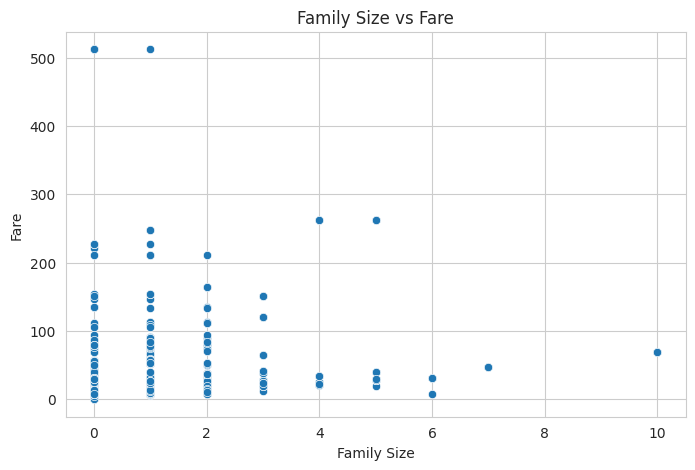

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='FamilySize', y='Fare', data=df)

plt.title('Family Size vs Fare')
plt.xlabel('Family Size')
plt.ylabel('Fare')
plt.show()

Interpretation

Passengers with larger families generally paid higher fares.

However, variation exists.

Question:6 Create a countplot to show survival count by gender.

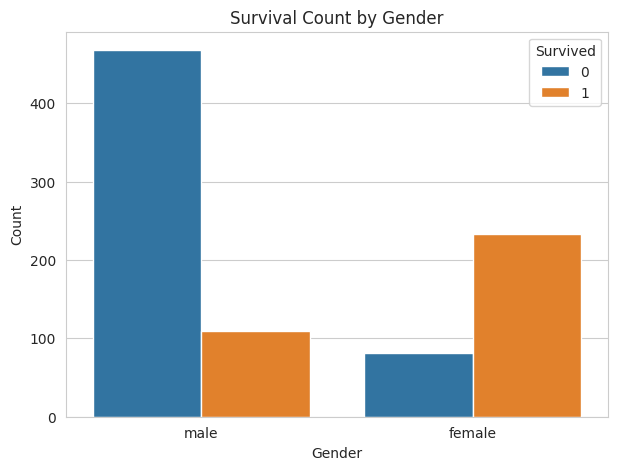

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Interpretation

Females had much higher survival rates.

Most male passengers did not survive.

Question:7 Create a bar chart to show survival by passenger class.

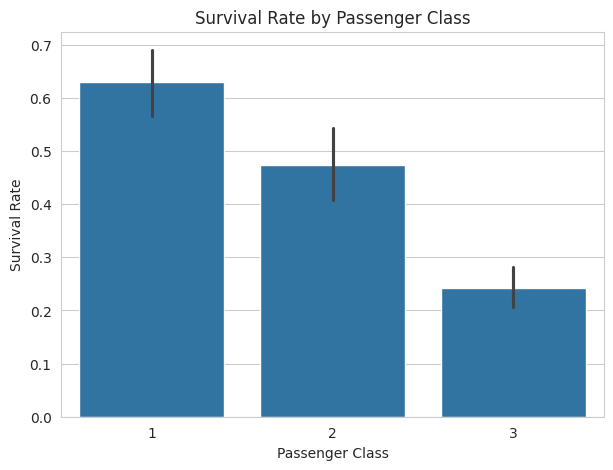

In [17]:
plt.figure(figsize=(7,5))

sns.barplot(x='Pclass', y='Survived', data=df)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

Interpretation

First-class passengers had the highest survival rate.

Third-class passengers had the lowest survival rate.

Question:8 Create a heatmap to show correlation between numerical variables.

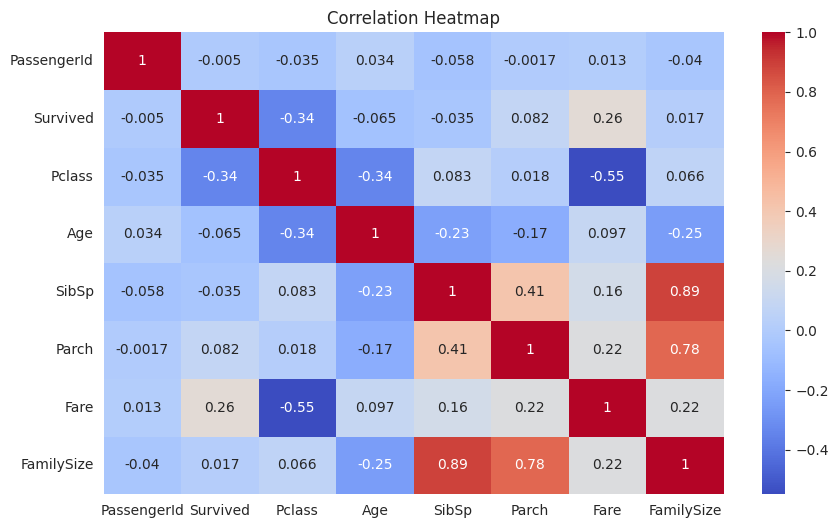

In [18]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

Interpretation

Fare is negatively correlated with Pclass.

Survival has positive correlation with Fare.

Survival has negative correlation with Pclass.

Question:9 Identify which passenger class paid the highest fare on average.

In [19]:
avg_fare = df.groupby('Pclass')['Fare'].mean()

print(avg_fare)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


Answer


Passenger Class 1 paid the highest average fare (≈ 84.15)

Question:10 Write at least 5 insights from the dataset based on your visualizations.

Answer:

Insight 1

Female passengers had a much higher survival rate than male passengers.

Insight 2

Most passengers belonged to Third Class.

Insight 3

First-class passengers paid significantly higher fares.

Insight 4

Passengers aged 20–40 years formed the majority of travelers.

Insight 5

First-class passengers had the highest survival probability, while third-class passengers had the lowest.

Insight 6

Fare contains several extreme outliers indicating luxury tickets.

Insight 7

No strong relationship exists between age and fare.